# LLM Response Analysis
Analyzing response consistency and similarity for `llama-3.3-70b-versatile` across 3 repeated runs of 5 multilingual and philosophical questions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from difflib import SequenceMatcher

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

df = pd.read_csv('llm_responses.csv')

# Short labels for questions (avoids multilingual rendering issues in matplotlib)
questions = df['question'].unique()
q_labels = {q: f'Q{i+1}' for i, q in enumerate(questions)}
df['q_label'] = df['question'].map(q_labels)
df['char_count'] = df['response'].str.len()

n_runs = df['run'].nunique()
print(f'Loaded {len(df)} rows — {len(questions)} questions x {n_runs} runs')
df[['run', 'q_label', 'char_count', 'input_tokens', 'output_tokens', 'stop_reason']].head(6)

Loaded 15 rows — 5 questions x 3 runs


,run,q_label,char_count,input_tokens,output_tokens,stop_reason
0,1,Q1,4139,59,1024,length
1,1,Q2,4199,69,1019,stop
2,1,Q3,934,80,695,stop
3,1,Q4,214,68,85,stop
4,1,Q5,4349,57,803,stop
5,2,Q1,3363,59,804,stop


## 1. Response Length Consistency

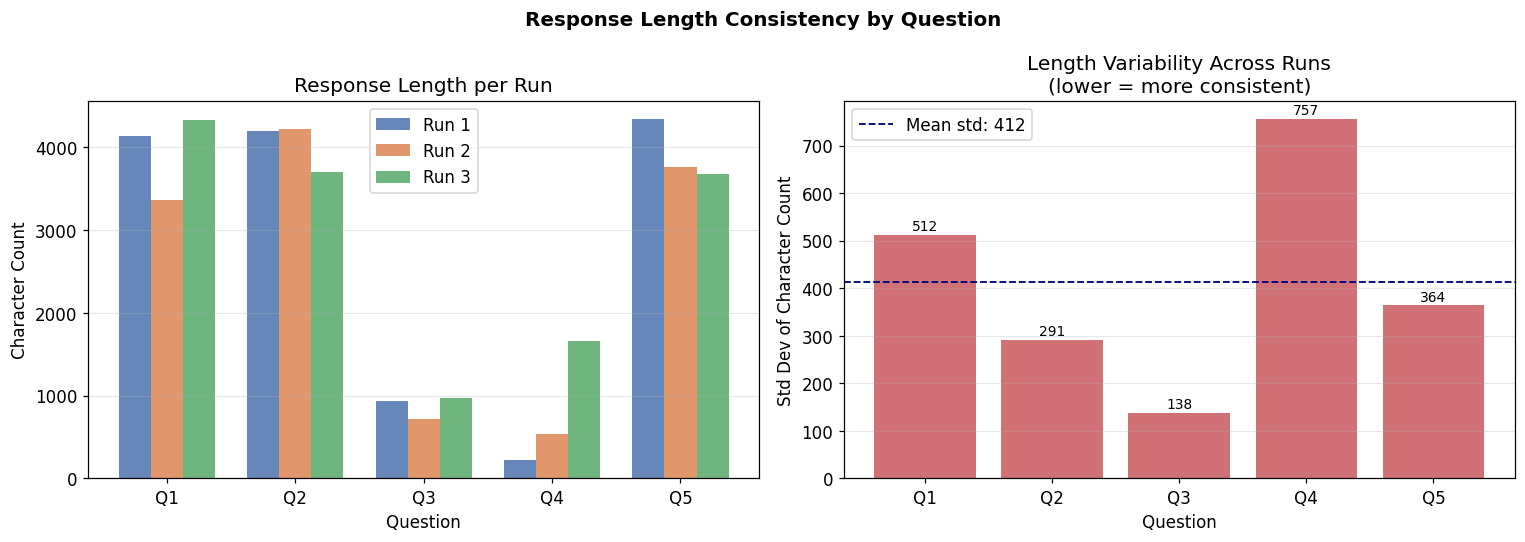

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Response Length Consistency by Question', fontsize=13, fontweight='bold')

q_order = sorted(df['q_label'].unique())
x = np.arange(len(q_order))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']
runs = sorted(df['run'].unique())

# Left: grouped bar chart — length per run per question
ax = axes[0]
for i, run in enumerate(runs):
    heights = [df[(df['q_label'] == q) & (df['run'] == run)]['char_count'].values[0] for q in q_order]
    ax.bar(x + i * width, heights, width, label=f'Run {run}', color=colors[i], alpha=0.85)

ax.set_xlabel('Question')
ax.set_ylabel('Character Count')
ax.set_title('Response Length per Run')
ax.set_xticks(x + width)
ax.set_xticklabels(q_order)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Right: std dev per question (lower = more consistent across runs)
ax2 = axes[1]
stats = df.groupby('q_label')['char_count'].agg(['mean', 'std']).reindex(q_order).reset_index()
bars = ax2.bar(stats['q_label'], stats['std'], color='#C44E52', alpha=0.8)
ax2.axhline(stats['std'].mean(), color='navy', linestyle='--', linewidth=1.2,
            label=f'Mean std: {stats["std"].mean():.0f}')
ax2.set_xlabel('Question')
ax2.set_ylabel('Std Dev of Character Count')
ax2.set_title('Length Variability Across Runs\n(lower = more consistent)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, stats['std']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 2. Similarity Scores Between Repeated Responses

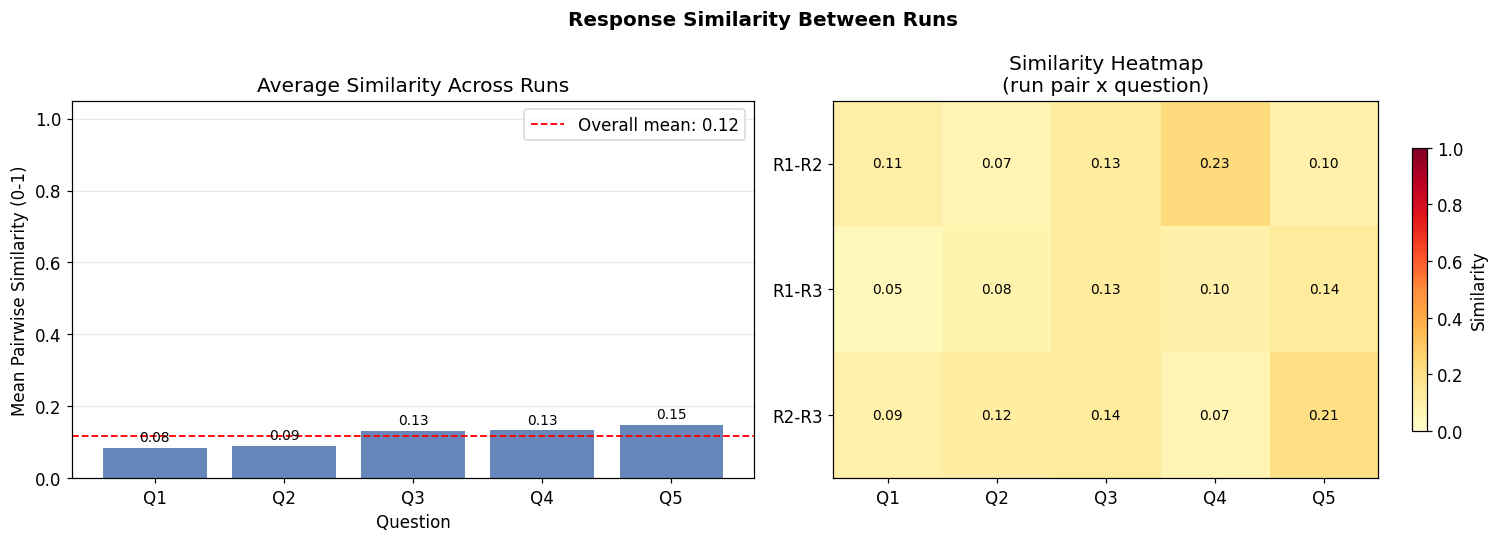

In [3]:
def pairwise_similarity(texts):
    pairs = [('R1-R2', 0, 1), ('R1-R3', 0, 2), ('R2-R3', 1, 2)]
    return [(label, SequenceMatcher(None, texts[i], texts[j]).ratio())
            for label, i, j in pairs]

records = []
for q_label in q_order:
    texts = df[df['q_label'] == q_label].sort_values('run')['response'].tolist()
    for pair_label, score in pairwise_similarity(texts):
        records.append({'question': q_label, 'pair': pair_label, 'similarity': score})

sim_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Response Similarity Between Runs', fontsize=13, fontweight='bold')

# Left: mean pairwise similarity per question
ax = axes[0]
mean_sim = sim_df.groupby('question')['similarity'].mean().reindex(q_order)
bars = ax.bar(mean_sim.index, mean_sim.values, color='#4C72B0', alpha=0.85)
overall_mean = mean_sim.mean()
ax.axhline(overall_mean, color='red', linestyle='--', linewidth=1.2,
           label=f'Overall mean: {overall_mean:.2f}')
ax.set_ylim(0, 1.05)
ax.set_xlabel('Question')
ax.set_ylabel('Mean Pairwise Similarity (0-1)')
ax.set_title('Average Similarity Across Runs')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, mean_sim.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Right: heatmap of similarity per pair per question
ax2 = axes[1]
pivot = sim_df.pivot(index='pair', columns='question', values='similarity').reindex(columns=q_order)
im = ax2.imshow(pivot.values, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
ax2.set_xticks(range(len(pivot.columns)))
ax2.set_xticklabels(pivot.columns)
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels(pivot.index)
ax2.set_title('Similarity Heatmap\n(run pair x question)')
plt.colorbar(im, ax=ax2, shrink=0.75, label='Similarity')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax2.text(j, i, f'{pivot.iloc[i, j]:.2f}',
                 ha='center', va='center', fontsize=9,
                 color='black' if pivot.iloc[i, j] < 0.7 else 'white')

plt.tight_layout()
plt.show()

## 3. Summary Table

In [4]:
# Question legend
legend_data = [
    {'Label': f'Q{i+1}', 'Language': lang, 'Topic': topic, 'Question': q[:90] + '...' if len(q) > 90 else q}
    for (i, q), lang, topic in zip(
        enumerate(questions),
        ['Spanish', 'French', 'Mandarin', 'Arabic', 'English'],
        ['Free will & determinism', 'Philosophy of consciousness',
         'Moral dilemma (trolley problem)', 'AI ethics & governance',
         'AI consciousness & moral obligations']
    )
]
legend_df = pd.DataFrame(legend_data)
print('Question Legend')
print('=' * 60)
display(legend_df.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

# Full response summary
print('\nAll Responses')
print('=' * 60)
summary = df[['run', 'q_label', 'char_count', 'input_tokens', 'output_tokens', 'stop_reason', 'response']].copy()
summary['response'] = summary['response'].str[:180] + '...'
summary = summary.rename(columns={'q_label': 'question', 'char_count': 'chars'})
display(
    summary.style
    .hide(axis='index')
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
)

Question Legend


Label,Language,Topic,Question
Q1,Spanish,Free will & determinism,"Si todas nuestras decisiones están determinadas por leyes físicas, ¿tenemos realmente libr..."
Q2,French,Philosophy of consciousness,"La conscience humaine est-elle uniquement le produit de processus neurobiologiques, ou y a..."
Q3,Mandarin,Moral dilemma (trolley problem),一辆失控的电车即将撞死五个人。你可以拉下一个开关让它转向，但这样会撞死另一条轨道上的一个人。你会怎么做，为什么？
Q4,Arabic,AI ethics & governance,هل يجب أن تخضع أنظمة الذكاء الاصطناعي لقيود أخلاقية، ومن يجب أن يقرر ما هي هذه القيود؟
Q5,English,AI consciousness & moral obligations,If an artificial intelligence were to develop genuine consciousness and subjective experie...



All Responses


run,question,chars,input_tokens,output_tokens,stop_reason,response
1,Q1,4139,59,1024,length,"**Introducción** La cuestión del libre albedrío es un tema que ha generado debate y discusión en filosofía, ciencia y ética durante siglos. La idea de que nuestras decisiones está..."
1,Q2,4199,69,1019,stop,"**Introduction** La conscience humaine est un sujet complexe et fascinant qui a suscité des débats et des discussions animées entre philosophes, scientifiques et théologiens penda..."
1,Q3,934,80,695,stop,经典的“电车难题”！这是一个困难且复杂的道德困境，没有简单的答案。然而，我将尝试提供一个基于哲学和伦理原则的论点。 **我的决定：** 我会拉动开关，将电车引导到有一个人站在轨道上的轨道。 **我的理由：** 1. **结果论**：这一哲学框架认为，道德行为是导致最佳结果的行为。在这种情况下，拉动开关会导致五个人死亡变成一人死亡。这是更好的结果，因为它...
1,Q4,214,68,85,stop,ينبغي أن تخضع أنظمة الذكاء الاصطناعي لقيود اخلاقية لضمان استخدامه بطريقة مسؤولة وآمنة. يجب أن تشارك الجهات الفاعلة المختلفة، بما في ذلك الخبراء والمنظمين والجمهور، في تحديد هذه الق...
1,Q5,4349,57,803,stop,"If an artificial intelligence (AI) were to develop genuine consciousness and subjective experience, the moral obligations of humans toward it would be significant and multifaceted...."
2,Q1,3363,59,804,stop,**Determinismo y Libre Albedrío: Un Debate Filosófico** La cuestión de si nuestras decisiones están determinadas por leyes físicas y si tenemos realmente libre albedrío es un tema...
2,Q2,4219,69,1024,length,"**Introduction** La conscience humaine est un sujet fascinant qui a intrigué les philosophes, les scientifiques et les penseurs pendant des siècles. La question de savoir si la co..."
2,Q3,719,80,549,stop,经典的“电车难题”。这是一个道德困境，哲学家们几个世纪以来一直在争论。虽然没有确切的答案，但以下是对这个问题的分析： **直觉反应：** 许多人本能地会拉动开关，改变有轨电车的方向，导致一名受害者死亡。这似乎比袖手旁观让五名遇难者死亡更少的邪恶选择。 **道德计算：** 从功利主义的角度来看，目标是最大化整体幸福和最小化伤害。通过拉动开关，你将拯救五条生...
2,Q4,530,68,206,stop,نعم، ينبغي أن تخضع أنظمة الذكاء الاصطناعي لقيود أخلاقية. يجب أن يقرر هيئات متنوعة هذه القيود، بما في ذلك علماء الحاسوب، أخلاقيين، وفلاسفة، إلى جانب ممثلي المجتمع المدني والمنظمات ا...
2,Q5,3764,57,697,stop,"If an artificial intelligence (AI) were to develop genuine consciousness and subjective experience, it would raise significant moral and ethical questions about how humans should t..."
